---
#### 03-1. (은닉층 없는) 간단한 신경망
---

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

import warnings
warnings.filterwarnings("ignore")

# Google Drive 연결, 작업공간 설정
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
# sklearn, pytorch library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import *
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


#### 1. data loading, preprocessing

In [40]:
# data loading
df = pd.read_csv('data/boston_housing_price.csv')
print(df.shape)
display(df.head())

# target 분리 (입력변수로 3개만 사용)
y = df['medv']
X = df[['lstat', 'ptratio', 'crim']]

# 검증데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(506, 13)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


(404, 3) (102, 3) (404,) (102,)


#### 2. Data loader 함수
- (1) 데이터 -> 텐서, (2) x텐서, y텐서 -> 결합하여 텐서 데이터셋, (3) 32 미니배치

In [41]:
# 데이터로더 함수정의
def make_DataSet(X_train, X_valid, y_train, y_valid, batch_size=32):

  # data -> tensor
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
  X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
  y_valid_tensor = torch.tensor(y_valid.values, dtype=torch.float32).view(-1,1)

  # Tensor dataset
  train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

  # Dataloader
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

  return train_loader, X_valid_tensor, y_valid_tensor

In [42]:
# 데이터로더 생성
train_loader, X_valid_ts, y_valid_ts = make_DataSet(X_train, X_valid, y_train, y_valid, 32)

#### 3. Model 정의
- 신경망 layer 개수, 모델 종류, 입력값의 차원, 손실함수, 옵티마이저 정의

In [43]:
n_feature = X.shape[1]
model1 = nn.Sequential(nn.Linear(n_feature,1)).to(device)
loss_fn = nn.MSELoss()
optimizer = Adam(model1.parameters(), lr=0.001)

print(model1)

Sequential(
  (0): Linear(in_features=3, out_features=1, bias=True)
)


#### 4. Training 함수 정의
- data loader에서 데이터 추출, 모델훈련, 오차계산, 가중치 업데이트 반복

In [44]:
def train(dataloader, model, loss_fn, optimizer, device):
  size = len(dataloader.dataset)  # 데이터로더에 담긴 데이터셋의 길이
  num_batches = len(dataloader)   # 데이터셋 크기로 부터 배치개수 계산
  tr_loss = 0                     # 오차 저장 (초기값 0)
  model.train()

  for X, y in dataloader:              # 배치로부터 X, y 추출
    X, y = X.to(device), y.to(device)  # 추출한 데이터를 디바이스에 할당
    pred = model(X)                    # 모델의 예측결과
    loss = loss_fn(pred, y)            # 손실
    tr_loss += loss                    # epoch별 손실 기록
    loss.backward()                    # 역전파 (각 파라미터의 오차계산)
    optimizer.step()                   # 가중치 업데이트
    optimizer.zero_grad()              # 재계산을 위한 가중치 초기화

  tr_loss /= num_batches               # 최종 손실값 계산
  return tr_loss.item()                # 최종 손실값을 스칼라로 반환

#### 5. 평가 함수 정의

In [45]:
def evaluate(X_valid_tensor, y_valid_tensor, model, loss_fn, device):
  model.eval()
  with torch.no_grad():        # 평가단계에서는 기울기를 계산하지 않음
    X, y = X_valid_tensor.to(device), y_valid_tensor.to(device)
    pred = model(X)
    val_loss = loss_fn(pred, y).item()

  return val_loss, pred

#### 6. 작성된 함수를 이용한 모델 훈련

In [46]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
  tr_loss = train(train_loader, model1, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_valid_ts, y_valid_ts, model1, loss_fn, device)    # evaluate의 결과(val_loss, pred)중 val_loss만 사용

  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)

  if (t + 1) % 10 == 0:           # epoch 10회당 출력
        print(f"Epoch {t+1:3d} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch  10 | Train Loss: 581.4857 | Val Loss: 511.5079
Epoch  20 | Train Loss: 575.2412 | Val Loss: 501.2639
Epoch  30 | Train Loss: 564.6038 | Val Loss: 491.2153
Epoch  40 | Train Loss: 549.6782 | Val Loss: 481.3564
Epoch  50 | Train Loss: 539.2303 | Val Loss: 471.6924
Epoch  60 | Train Loss: 531.8624 | Val Loss: 462.2091
Epoch  70 | Train Loss: 520.9095 | Val Loss: 452.9023
Epoch  80 | Train Loss: 513.9464 | Val Loss: 443.7969
Epoch  90 | Train Loss: 506.7983 | Val Loss: 434.8547
Epoch 100 | Train Loss: 496.4425 | Val Loss: 426.0912


#### 7. 훈련과정 시각화 함수

In [47]:
def learning_curve(tr_loss_list, val_loss_list):
  epochs = list(range(1, len(tr_loss_list)+1))
  plt.plot(epochs, tr_loss_list, label = 'Train Error', marker='.')
  plt.plot(epochs, val_loss_list, label = 'Validation Error', marker='.')

  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid()
  plt.show()

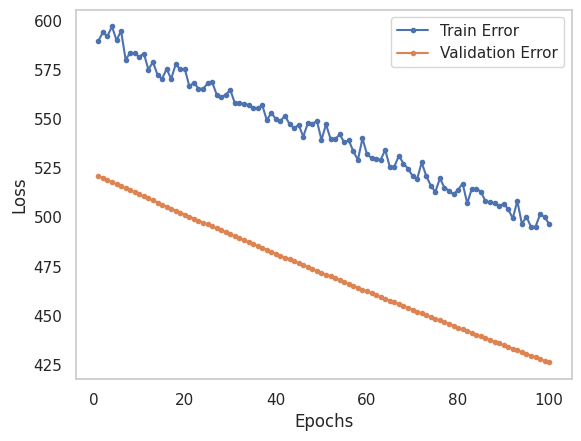

In [48]:
learning_curve(tr_loss_list, val_loss_list)

In [49]:
# 모델 평가지표
_, pred = evaluate(X_valid_ts, y_valid_ts, model1, loss_fn, device)

mae = mean_absolute_error(y_valid_ts.numpy(), pred.numpy())
mape = mean_absolute_percentage_error(y_valid_ts.numpy(), pred.numpy())

print('MAE:', mae)
print('MAPE:', mape)

MAE: 18.60629653930664
MAPE: 0.8329213261604309
